# Notebook to check the MNase-seq length distributions, and compute normalization scaling values

We will read in the MNase-seq bam files collect the length distribution of each sample in the time series, plot the length distributions color coded by time. And compute scaling value for each length value.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from src.chromatin_metrics import ChromatinMetrics, yl_rep2_len_spans

small_frag_span, mid_frag_span, nucleosome_len_span = yl_rep2_len_spans()

filename = '../_archive/data/bam/cell_cycle/mnase/DMAH64_MNase_rep1_0_min.bam'
sample_name = 0

chromatin_metrics = ChromatinMetrics(nucleosome_len_span, mid_frag_span, small_frag_span)
chromatin_metrics.read_bam_file(filename, sample_name)


Chromosome 1 - 00:00:00.02
Chromosome 8 - 00:00:14.37
Chromosome 16 - 00:00:33.70


In [5]:
chromatin_metrics.compute_length_hist()

The minimum length of reads is 27, the maximal length is 250.


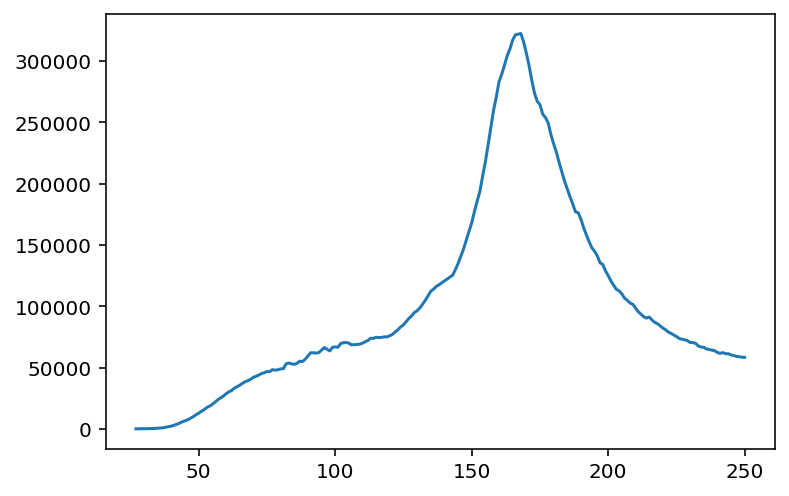

In [6]:
# Plot length value, so don't include the last bin edge
plt.plot(chromatin_metrics.bins[:-1], chromatin_metrics.counts)


In [7]:
from src.timer import Timer

# Now, let's do this for all timepoints and see what they look like combined...
        
replicate2_filenames = [(0, '../_archive/data/bam/cell_cycle/mnase/DMAH82_MNase_rep2_0_min.bam'),
                         (10, '../_archive/data/bam/cell_cycle/mnase/DMAH83_MNase_rep2_10_min.bam'),
                         (20, '../_archive/data/bam/cell_cycle/mnase/DMAH84_MNase_rep2_20_min.bam'),
                         (30, '../_archive/data/bam/cell_cycle/mnase/DMAH85_MNase_rep2_30_min.bam'),
                         (40, '../_archive/data/bam/cell_cycle/mnase/DMAH86_MNase_rep2_40_min.bam'),
                         (50, '../_archive/data/bam/cell_cycle/mnase/DMAH87_MNase_rep2_50_min.bam'),
                         (60, '../_archive/data/bam/cell_cycle/mnase/DMAH88_MNase_rep2_60_min.bam'),
                         (70, '../_archive/data/bam/cell_cycle/mnase/DMAH89_MNase_rep2_70_min.bam'),
                         (80, '../_archive/data/bam/cell_cycle/mnase/DMAH90_MNase_rep2_80_min.bam'),
                         (90, '../_archive/data/bam/cell_cycle/mnase/DMAH91_MNase_rep2_90_min.bam'),
                         (100, '../_archive/data/bam/cell_cycle/mnase/DMAH92_MNase_rep2_100_min.bam'),
                         (110, '../_archive/data/bam/cell_cycle/mnase/DMAH93_MNase_rep2_110_min.bam'),
                         (120, '../_archive/data/bam/cell_cycle/mnase/DMAH94_MNase_rep2_120_min.bam'),
                         (130, '../_archive/data/bam/cell_cycle/mnase/DMAH95_MNase_rep2_130_min.bam'),
                         (140, '../_archive/data/bam/cell_cycle/mnase/DMAH96_MNase_rep2_140_min.bam')]

nucleosome_len_span = (145, 195)
mid_frag_span = (100, 145)
small_frag_span = (0, 100)

bins_dic = {}
counts_dic = {}

timer = Timer()

for time, filepath in replicate2_filenames:

    print(f"For time {time}")
    
    sample_name = time

    chromatin_metrics = ChromatinMetrics(nucleosome_len_span, mid_frag_span, small_frag_span)
    chromatin_metrics.read_bam_file(filepath, sample_name)

    chromatin_metrics.compute_length_hist()
    
    bins_dic[time] = chromatin_metrics.bins
    counts_dic[time] = chromatin_metrics.counts
    print(f"{timer.get_time()}")
    

For time 0
Chromosome 1 - 00:00:00.04
Chromosome 8 - 00:00:15.38
Chromosome 16 - 00:00:36.40
The minimum length of reads is 27, the maximal length is 250.
00:01:08.46
For time 10
Chromosome 1 - 00:00:00.05
Chromosome 8 - 00:00:17.19
Chromosome 16 - 00:00:40.30
The minimum length of reads is 27, the maximal length is 250.
00:02:24.66
For time 20
Chromosome 1 - 00:00:00.05
Chromosome 8 - 00:00:16.81
Chromosome 16 - 00:00:39.64
The minimum length of reads is 27, the maximal length is 250.
00:03:39.94
For time 30
Chromosome 1 - 00:00:00.05
Chromosome 8 - 00:00:19.31
Chromosome 16 - 00:00:45.87
The minimum length of reads is 27, the maximal length is 250.
00:05:08.88
For time 40
Chromosome 1 - 00:00:00.06
Chromosome 8 - 00:00:21.80
Chromosome 16 - 00:00:51.23
The minimum length of reads is 27, the maximal length is 250.
00:06:49.01
For time 50
Chromosome 1 - 00:00:00.06
Chromosome 8 - 00:00:20.31
Chromosome 16 - 00:00:48.03
The minimum length of reads is 27, the maximal length is 250.
00:08

In [8]:
bin_cols = bins_dic[0][:-1]
times = [row[0] for row in replicate2_filenames]
len_counts_df = pd.DataFrame(columns=bin_cols, index=times)
for time, row in len_counts_df.iterrows():
    counts = counts_dic[time]
    len_counts_df.loc[time] = counts
len_counts_df.to_csv('output/yl_rep2_len_dist.csv')

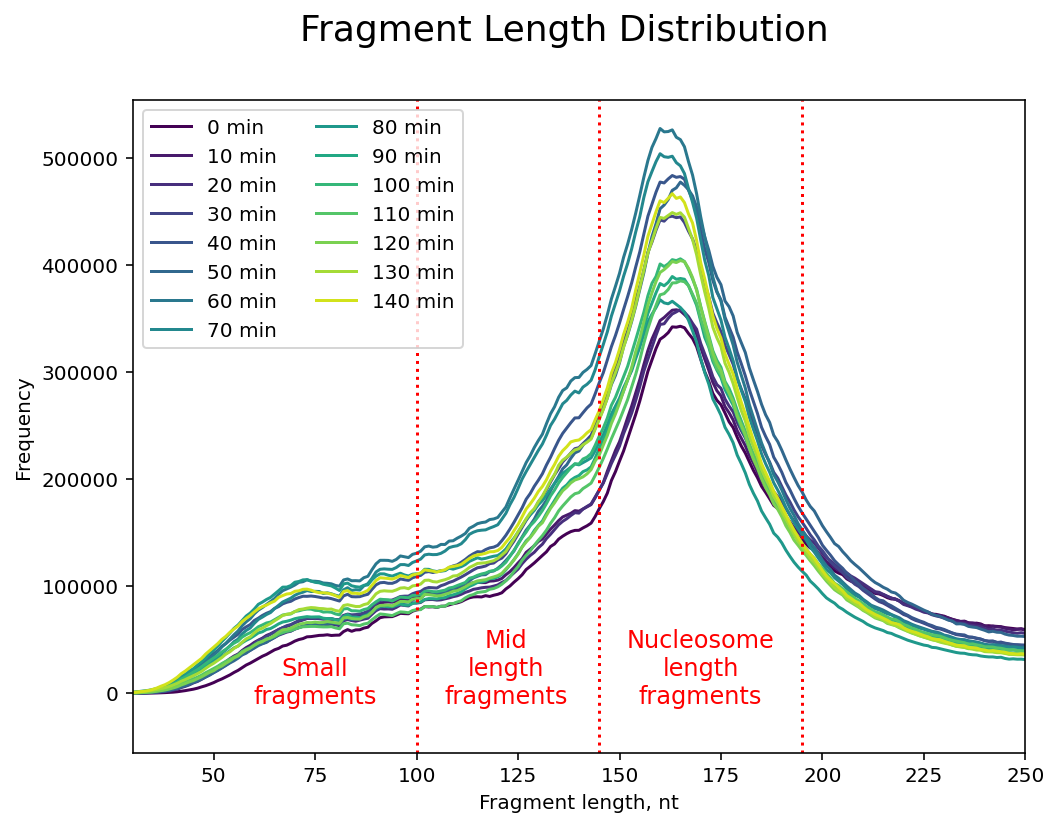

In [53]:

def plot_len_counts(len_counts_df):
    plt.figure(figsize=(8, 6))
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i/(len(len_counts_df))) for i in range(len(len_counts_df))]

    for i in range(len(len_counts_df)):
        row = len_counts_df.iloc[i]
        plt.plot(row, color=colors[i], label=f"{row.name} min")
    plt.legend(ncol=2)
    plt.xlim(30, 250)
    
plot_len_counts(len_counts_df)

og_max_ylim = plt.ylim()[1]
og_ylim = -og_max_ylim*0.1, og_max_ylim

y = -og_max_ylim*0.025
plt.text(small_frag_span[1]//2+25, y, "Small\nfragments", ha='center', va='bottom',
         color='red', fontsize=12)
plt.text((mid_frag_span[1]+mid_frag_span[0])//2, y, "Mid\nlength\nfragments", 
         ha='center', va='bottom', 
         color='red', fontsize=12)
plt.text((nucleosome_len_span[1]+nucleosome_len_span[0])//2, y,
         "Nucleosome\nlength\nfragments", ha='center', va='bottom',
         color='red', fontsize=12)
plt.xlabel("Fragment length, nt")
plt.ylabel("Frequency")
plt.suptitle("Fragment Length Distribution", fontsize=18)

plt.ylim(*og_ylim)
for len_spans in [small_frag_span, mid_frag_span, nucleosome_len_span]:
    plt.axvline(len_spans[1], linestyle='dotted', c='red')


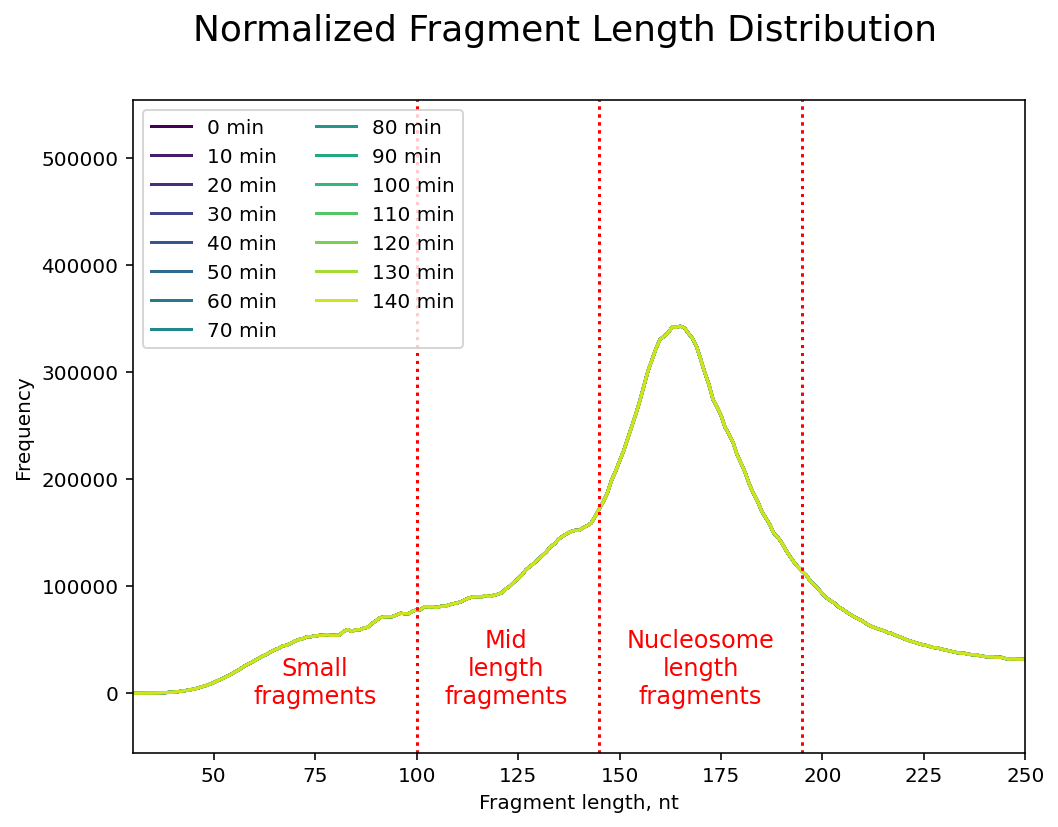

In [52]:
# Compute the minimum fragment occupancy for each length (what time had the fewest number of reads for 
# a given fragment length)
min_counts_per_len = len_counts_df.min(axis=0)

# Then compute a scaling matrix, the factor in which we need to multiply the
# lengths matrix in order for each timepoint to be equivalent to this min counts vector
min_len_scaling_matrix = min_counts_per_len / len_counts_df

# Test the scaling matrix, we should now have all of the length distributions on the same curve
scaled_lens_df = len_counts_df * min_len_scaling_matrix
plot_len_counts(scaled_lens_df)
for len_spans in [small_frag_span, mid_frag_span, nucleosome_len_span]:
    plt.axvline(len_spans[1], linestyle='dotted', c='red')

y = -og_max_ylim*0.025
plt.text(small_frag_span[1]//2+25, y, "Small\nfragments", ha='center', va='bottom',
         color='red', fontsize=12)
plt.text((mid_frag_span[1]+mid_frag_span[0])//2, y, "Mid\nlength\nfragments", ha='center', va='bottom', 
         color='red', fontsize=12)
plt.text((nucleosome_len_span[1]+nucleosome_len_span[0])//2, y,
         "Nucleosome\nlength\nfragments", ha='center', va='bottom', color='red', fontsize=12)
plt.ylim(-plt.ylim()[1]*0.1, plt.ylim()[1])
for len_spans in [small_frag_span, mid_frag_span, nucleosome_len_span]:
    plt.axvline(len_spans[1], linestyle='dotted', c='red')
plt.ylim(*og_ylim)
plt.xlabel("Fragment length, nt")
plt.ylabel("Frequency")
plt.suptitle("Normalized Fragment Length Distribution", fontsize=18)

# Save the scaling matrix so we can use it later for normalization
min_len_scaling_matrix.index.names = ['time']
min_len_scaling_matrix.to_csv('output/yl_rep2_mnase_min_len_scaling_mat.csv')
